<a href="https://colab.research.google.com/github/Aysha2004/S7_INTERNSHIP/blob/main/Drowsiness_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile

zip_path = "/content/archive (4).zip"
extract_path = "/content/drowsiness_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted")

Dataset Extracted


In [3]:
import os

zip_path = "/content/archive (4).zip"
extract_path = "/content/drowsiness_dataset"

train_path = "/content/drowsiness_dataset/Dataset/Train"
val_path = "/content/drowsiness_dataset/Dataset/Val"
test_path = "/content/drowsiness_dataset/Dataset/Test"

print(f"Contents of {extract_path}:")
print(os.listdir(extract_path))

Contents of /content/drowsiness_dataset:
['Dataset']


In [4]:
import os

# The previous error indicates that 'train_path' is not found.
# Let's inspect the contents of the directory one level up to understand the structure.

dataset_parent_path = os.path.dirname(train_path) # This should be /content/drowsiness_dataset/Dataset

print(f"Contents of {dataset_parent_path}:")
print(os.listdir(dataset_parent_path))

Contents of /content/drowsiness_dataset/Dataset:
['Test', 'Val', 'Train']


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 8548 images belonging to 4 classes.
Found 1554 images belonging to 4 classes.
Found 1464 images belonging to 4 classes.


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        4,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)

Epoch 1/2
268/268 ━━━━━━━━━━━━━━━━━━━━ 1155s 4s/step - accuracy: 0.7635 - loss: 0.6162 - val_accuracy: 0.9228 - val_loss: 0.2612
Epoch 2/2
268/268 ━━━━━━━━━━━━━━━━━━━━ 1170s 4s/step - accuracy: 0.8567 - loss: 0.3894 - val_accuracy: 0.9466 - val_loss: 0.2094


In [9]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    test_generator
)

print("CNN Accuracy:", cnn_acc)

46/46 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9016 - loss: 0.2886
CNN Accuracy: 0.9016393423080444


In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        4,
        activation='softmax'
    )
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)

Epoch 1/2
268/268 ━━━━━━━━━━━━━━━━━━━━ 577s 2s/step - accuracy: 0.9138 - loss: 0.2438 - val_accuracy: 0.9665 - val_loss: 0.1036
Epoch 2/2
268/268 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.9527 - loss: 0.1354 - val_accuracy: 0.9762 - val_loss: 0.0804


In [12]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(
    test_generator
)

print("MobileNetV2 Accuracy:", mobile_acc)

46/46 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9419 - loss: 0.1538
MobileNetV2 Accuracy: 0.9419398903846741


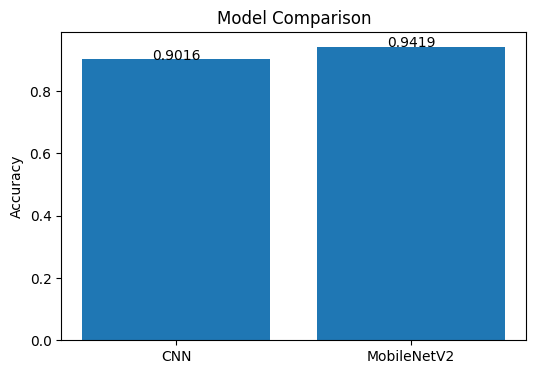

In [13]:
import matplotlib.pyplot as plt

models = [
    "CNN",
    "MobileNetV2"
]

accuracies = [
    cnn_acc,
    mobile_acc
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    accuracies
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

for i,v in enumerate(accuracies):
    plt.text(
        i,
        v,
        f"{v:.4f}",
        ha='center'
    )

plt.show()

In [14]:
mobilenet_model.save(
    "drowsiness_model.h5"
)

In [15]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream =
          await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(
          document.body.scrollHeight,
          true
      );

      await new Promise(
          (resolve) => capture.onclick = resolve
      );

      const canvas = document.createElement('canvas');

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas
          .getContext('2d')
          .drawImage(video, 0, 0);

      stream.getTracks().forEach(
          track => track.stop()
      );

      div.remove();

      return canvas.toDataURL(
          'image/jpeg',
          quality
      );
    }
    ''')

    display(js)

    data = eval_js(
        'takePhoto({})'.format(quality)
    )

    binary = b64decode(
        data.split(',')[1]
    )

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [30]:
image_path = take_photo()

print("Captured:", image_path)

<IPython.core.display.Javascript object>

Captured: photo.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


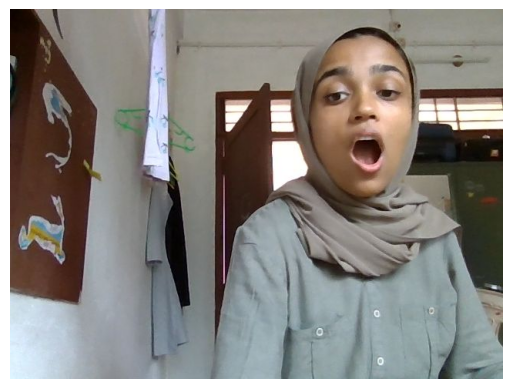

Prediction: Yawn
Confidence: 88.4 %


In [31]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "Closed_Eyes",
    "No_yawn",
    "Open_Eyes",
    "Yawn"
]

img = image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = mobilenet_model.predict(img_array)

predicted_class = np.argmax(
    prediction
)

confidence = np.max(
    prediction
)

plt.imshow(
    image.load_img(image_path)
)

plt.axis("off")
plt.show()

print(
    "Prediction:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    round(confidence*100,2),
    "%"
)

In [32]:
if class_names[predicted_class] in [
    "Closed_Eyes",
    "Yawn"
]:
    print("⚠️ DROWSINESS DETECTED")

else:
    print("✅ DRIVER ALERT")

⚠️ DROWSINESS DETECTED
